In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [1]:
import sys
print(sys.executable)
print(sys.version)

C:\Python312\python.exe
3.12.4 (tags/v3.12.4:8e8a4ba, Jun  6 2024, 19:30:16) [MSC v.1940 64 bit (AMD64)]


In [ ]:
books   = pd.read_csv(r"C:\Users\Jasin\OneDrive\Desktop\book system\Books.csv",   encoding="latin-1", on_bad_lines="skip", low_memory=False, sep=",", quotechar='"')
ratings = pd.read_csv(r"C:\Users\Jasin\OneDrive\Desktop\book system\Ratings.csv", encoding="latin-1", on_bad_lines="skip", sep=",", quotechar='"')
users   = pd.read_csv(r"C:\Users\Jasin\OneDrive\Desktop\book system\Users.csv",   encoding="latin-1", on_bad_lines="skip", sep=",", quotechar='"')

books.columns   = ["ISBN", "Title", "Author", "Year", "Publisher", "Img-S", "Img-M", "Img-L"]
ratings.columns = ["User-ID", "ISBN", "Rating"]
users.columns   = ["User-ID", "Location", "Age"]

print(books.shape, ratings.shape, users.shape)

(271360, 8) (1149780, 3) (278858, 3)



── Books Sample ──
         ISBN                                              Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

                 Author  Year                   Publisher  \
0    Mark P. O. Morford  2002     Oxford University Press   
1  Richard Bruce Wright  2001       HarperFlamingo Canada   
2          Carlo D'Este  1991             HarperPerennial   
3      Gina Bari Kolata  1999        Farrar Straus Giroux   
4       E. J. W. Barber  1999  W. W. Norton &amp; Company   

                                               Img-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P

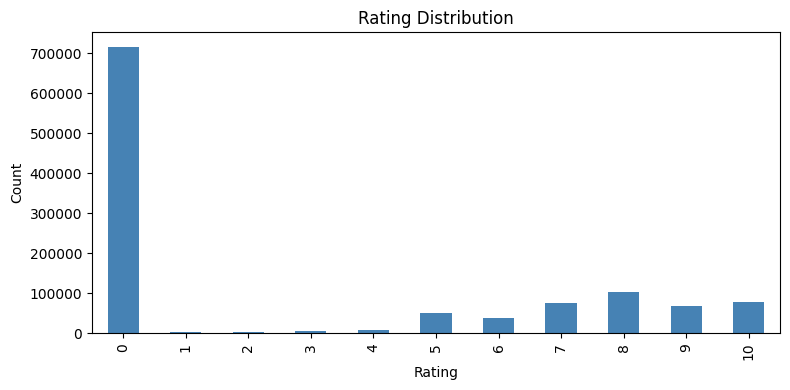


── Top 10 Most Rated Books ──
                                               Title  Rating
0                          The Lovely Bones: A Novel     707
1                                        Wild Animus     581
2                                  The Da Vinci Code     487
3                The Red Tent (Bestselling Backlist)     383
4                                                NaN     333
5    Divine Secrets of the Ya-Ya Sisterhood: A Novel     320
6  Harry Potter and the Sorcerer's Stone (Harry P...     313
7                            The Secret Life of Bees     307
8  Where the Heart Is (Oprah's Book Club (Paperba...     295
9                                    A Painted House     281


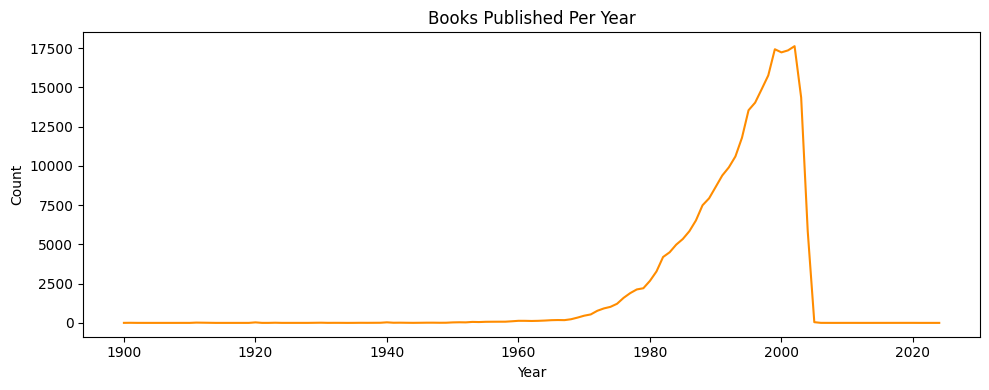

In [ ]:
print("\n── Books Sample ──")
print(books.head())

print("\n── Missing Values ──")
print(books.isnull().sum())

plt.figure(figsize=(8, 4))
ratings["Rating"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("rating_distribution.png")
plt.show()

top_books = (
    ratings[ratings["Rating"] > 0]
    .groupby("ISBN")["Rating"].count()
    .sort_values(ascending=False).head(10)
    .reset_index()
    .merge(books[["ISBN", "Title"]], on="ISBN", how="left")
)
print("\n── Top 10 Most Rated Books ──")
print(top_books[["Title", "Rating"]])

books["Year"] = pd.to_numeric(books["Year"], errors="coerce")
books_year = books[(books["Year"] >= 1900) & (books["Year"] <= 2024)]
plt.figure(figsize=(10, 4))
books_year["Year"].value_counts().sort_index().plot(kind="line", color="darkorange")
plt.title("Books Published Per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("books_per_year.png")
plt.show()

In [ ]:
books["Title_Clean"] = (
    books["Title"]
    .str.lower()
    .str.strip()
)

books = books.drop_duplicates(
    subset=["Title_Clean"],
    keep="first"
)
books.drop_duplicates(subset="ISBN", inplace=True)
books["Author"] = books["Author"].fillna("")
books["Publisher"] = books["Publisher"].fillna("")
books["Year"].fillna(0, inplace=True)

ratings = ratings[ratings["Rating"] > 0]

user_counts = ratings["User-ID"].value_counts()
book_counts = ratings["ISBN"].value_counts()
ratings = ratings[
    ratings["User-ID"].isin(user_counts[user_counts >= 50].index) &
    ratings["ISBN"].isin(book_counts[book_counts >= 10].index)
]
print(f"\nFiltered ratings shape: {ratings.shape}")


Filtered ratings shape: (47932, 3)


In [ ]:
books["features"] = (
    books["Title"].fillna("") + " " +
    books["Author"].fillna("")
)

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=15000,
    ngram_range=(1,2)
)
tfidf_matrix = tfidf.fit_transform(books["features"])

books.reset_index(drop=True, inplace=True)
title_to_idx = pd.Series(books.index, index=books["Title"].str.lower())


def content_based_recommend(book_title, n=10):
    book_title = book_title.lower()
    if book_title not in title_to_idx:
        print(f"Book '{book_title}' not found.")
        return pd.DataFrame()
    idx = title_to_idx[book_title]
    book_vec   = tfidf_matrix[idx]
    sim_scores = cosine_similarity(book_vec, tfidf_matrix).flatten()
    sim_scores[idx] = 0
    n = min(n, len(sim_scores) - 1)
    top_indices = np.argpartition(sim_scores, -n)[-n:]
    top_indices = top_indices[np.argsort(sim_scores[top_indices])[::-1]]
    top_indices = top_indices[top_indices < len(books)]
    result = books.iloc[top_indices][["Title", "Author", "Year", "Publisher"]].copy()
    result["Similarity"] = np.round(sim_scores[top_indices], 4)
    return result.reset_index(drop=True)

In [ ]:
collab_data = ratings.merge(books[["ISBN", "Title"]], on="ISBN", how="left").dropna(subset=["Title"])
pivot = collab_data.pivot_table(index="User-ID", columns="Title", values="Rating").fillna(0)
pivot_sparse = csr_matrix(pivot.values)

svd = TruncatedSVD(n_components=50, random_state=42)
svd.fit_transform(pivot_sparse)

book_latent = svd.components_.T
collab_sim  = cosine_similarity(book_latent)

book_titles_list    = list(pivot.columns)
collab_title_to_idx = {t.lower(): i for i, t in enumerate(book_titles_list)}


def collab_recommend(book_title, n=10):
    book_title = book_title.lower()
    if book_title not in collab_title_to_idx:
        print(f"Book '{book_title}' not found in collaborative data.")
        return pd.DataFrame()
    idx = collab_title_to_idx[book_title]
    sim_scores = sorted(enumerate(collab_sim[idx]), key=lambda x: x[1], reverse=True)[1:n+1]
    return pd.DataFrame({
        "Title":        [book_titles_list[i[0]] for i in sim_scores],
        "Collab-Score": [round(i[1], 4) for i in sim_scores]
    }).reset_index(drop=True)

In [ ]:
def hybrid_recommend(book_title, n=10, content_weight=0.5, collab_weight=0.5):
    cb = content_based_recommend(book_title, n=50)
    cf = collab_recommend(book_title, n=50)

    def normalize(series):
        mn, mx = series.min(), series.max()
        return (series - mn) / (mx - mn + 1e-9)

    if not cb.empty and cf.empty:
        cb["hybrid_score"] = normalize(cb["Similarity"])
        return cb[["Title", "Author", "Year", "Publisher", "hybrid_score"]].head(n).reset_index(drop=True)
    if cb.empty and not cf.empty:
        cf["hybrid_score"] = normalize(cf["Collab-Score"])
        return cf[["Title", "hybrid_score"]].head(n).reset_index(drop=True)
    if cb.empty and cf.empty:
        print("No recommendations found.")
        return pd.DataFrame()

    cb["cb_norm"] = normalize(cb["Similarity"])
    cf["cf_norm"] = normalize(cf["Collab-Score"])
    merged = pd.merge(
        cb[["Title", "Author", "Year", "Publisher", "cb_norm"]],
        cf[["Title", "cf_norm"]],
        on="Title", how="outer"
    ).fillna(0)
    merged["hybrid_score"] = content_weight * merged["cb_norm"] + collab_weight * merged["cf_norm"]
    return merged.sort_values("hybrid_score", ascending=False).head(n)[
        ["Title", "Author", "Year", "Publisher", "hybrid_score"]
    ].reset_index(drop=True)

In [ ]:
def catalog_coverage(recommend_fn, sample_titles, n=10):
    all_recs = set()
    for title in sample_titles:
        recs = recommend_fn(title, n=n)
        if not recs.empty:
            all_recs.update(recs["Title"].tolist())
    coverage = len(all_recs) / len(books) * 100
    print(f"Catalog Coverage: {coverage:.2f}%  ({len(all_recs)} unique books recommended)")
    return coverage


def intra_list_diversity(rec_titles):
    indices = [title_to_idx.get(t.lower()) for t in rec_titles if t.lower() in title_to_idx]
    indices = [i for i in indices if i is not None]
    if len(indices) < 2:
        return 0.0
    sub_sim = cosine_similarity(tfidf_matrix[indices])
    n = len(indices)
    avg_sim = (sub_sim.sum() - n) / (n * (n - 1))
    return round(1 - avg_sim, 4)


In [ ]:
def build_regression_features(ratings, books, svd_model, pivot):
    print("Building regression features...")
    user_stats = ratings.groupby("User-ID")["Rating"].agg(
        user_avg_rating="mean", user_rating_count="count"
    ).reset_index()
    book_stats = ratings.groupby("ISBN")["Rating"].agg(
        book_avg_rating="mean", book_rating_count="count"
    ).reset_index()
    df = ratings.copy()
    df = df.merge(user_stats, on="User-ID", how="left")
    df = df.merge(book_stats, on="ISBN",    how="left")
    df = df.merge(books[["ISBN", "Year"]],  on="ISBN", how="left")
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").fillna(0)
    user_idx = {uid: i for i, uid in enumerate(pivot.index)}
    book_idx = {isbn: i for i, isbn in enumerate(pivot.columns)}
    user_latent     = svd_model.transform(csr_matrix(pivot.values))
    book_latent_reg = svd_model.components_.T
    def get_svd_dot(row):
        u = user_idx.get(row["User-ID"])
        b = book_idx.get(row["ISBN"])
        if u is None or b is None:
            return 0.0
        return float(np.dot(user_latent[u], book_latent_reg[b]))
    df["svd_dot"] = df.apply(get_svd_dot, axis=1)
    feature_cols = ["user_avg_rating", "user_rating_count",
                    "book_avg_rating", "book_rating_count", "Year", "svd_dot"]
    df = df.dropna(subset=feature_cols)
    return df[feature_cols], df["Rating"], feature_cols


def train_regression_models(ratings, books, svd_model, pivot):
    X, y, feature_cols = build_regression_features(ratings, books, svd_model, pivot)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    models = {
        "Linear Regression": LinearRegression(),
        "Ridge Regression":  Ridge(alpha=1.0),
        "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    }
    results = {}
    trained = {}
    print(f"\n{'Model':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
    print("-" * 52)
    for name, model in models.items():
        if name in ["Random Forest", "Gradient Boosting"]:
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
        else:
            model.fit(X_train_sc, y_train)
            preds = model.predict(X_test_sc)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae  = mean_absolute_error(y_test, preds)
        r2   = r2_score(y_test, preds)
        results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
        trained[name] = (model, scaler if name not in ["Random Forest", "Gradient Boosting"] else None)
        print(f"{name:<25} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")
    plt.figure(figsize=(8, 4))
    bars = plt.bar(list(results.keys()), [results[m]["RMSE"] for m in results],
                   color=["steelblue", "coral", "mediumseagreen", "orchid"])
    plt.title("Model Comparison — RMSE (lower is better)")
    plt.ylabel("RMSE")
    plt.xticks(rotation=15, ha="right")
    for bar, val in zip(bars, [results[m]["RMSE"] for m in results]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
    rf_model = trained["Random Forest"][0]
    pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values().plot(
        kind="barh", color="steelblue", figsize=(7, 4), title="Feature Importance (Random Forest)")
    plt.tight_layout()
    plt.show()
    best = min(results, key=lambda m: results[m]["RMSE"])
    print(f"\nBest Model: {best}  (RMSE = {results[best]['RMSE']:.4f})")
    return trained, scaler, feature_cols, results


def predict_rating(user_id, isbn, trained_models, ratings, books, svd_model, pivot, model_name="Gradient Boosting"):
    user_stats = ratings.groupby("User-ID")["Rating"].agg(
        user_avg_rating="mean", user_rating_count="count"
    ).reset_index()
    book_stats = ratings.groupby("ISBN")["Rating"].agg(
        book_avg_rating="mean", book_rating_count="count"
    ).reset_index()
    u_row  = user_stats[user_stats["User-ID"] == user_id]
    b_row  = book_stats[book_stats["ISBN"] == isbn]
    b_info = books[books["ISBN"] == isbn]
    if u_row.empty or b_row.empty:
        print("User or book not found in training data.")
        return None
    user_idx_map  = {uid: i for i, uid in enumerate(pivot.index)}
    book_idx_map  = {b: i for i, b in enumerate(pivot.columns)}
    user_latent   = svd_model.transform(csr_matrix(pivot.values))
    book_latent_r = svd_model.components_.T
    u = user_idx_map.get(user_id)
    b = book_idx_map.get(isbn)
    svd_dot = float(np.dot(user_latent[u], book_latent_r[b])) if u is not None and b is not None else 0.0
    year = pd.to_numeric(b_info["Year"].values[0], errors="coerce") if not b_info.empty else 0
    features = pd.DataFrame([{
        "user_avg_rating":   u_row["user_avg_rating"].values[0],
        "user_rating_count": u_row["user_rating_count"].values[0],
        "book_avg_rating":   b_row["book_avg_rating"].values[0],
        "book_rating_count": b_row["book_rating_count"].values[0],
        "Year":              year,
        "svd_dot":           svd_dot,
    }])
    model, scaler = trained_models[model_name]
    if scaler:
        features = scaler.transform(features)
    predicted = np.clip(model.predict(features)[0], 1, 10)
    title = b_info["Title"].values[0] if not b_info.empty else isbn
    print(f"Predicted rating for User {user_id} on '{title}': {predicted:.2f} / 10")
    return predicted


  Recommendations for: 'Classical Mythology'

── Content-Based ──
                                              Title        Author   Year               Publisher  Similarity
Who's Who in Classical Mythology (Who's Who Series) Michael Grant 1993.0 Oxford University Press      0.7613

── Collaborative Filtering ──
Book 'classical mythology' not found in collaborative data.
Empty DataFrame
Columns: []
Index: []

── Hybrid (50/50) ──
Book 'classical mythology' not found in collaborative data.
                                                                     Title                Author   Year               Publisher  hybrid_score
                       Who's Who in Classical Mythology (Who's Who Series)         Michael Grant 1993.0 Oxford University Press      1.000000
                                           The Oxford Classical Dictionary      Simon Hornblower 1996.0 Oxford University Press      0.410682
                                 Dictionary of mythology, mainly classical    

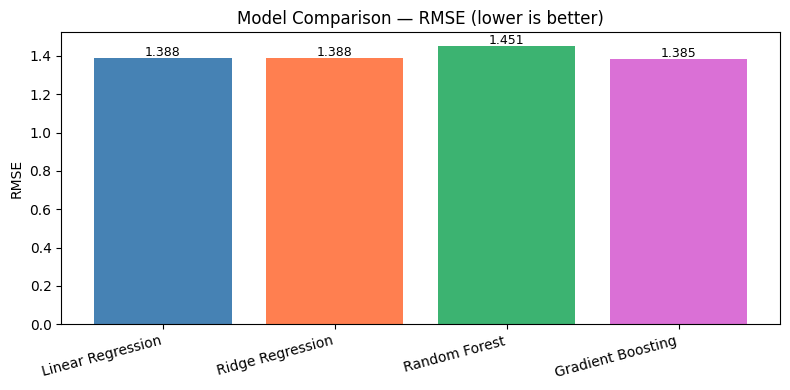

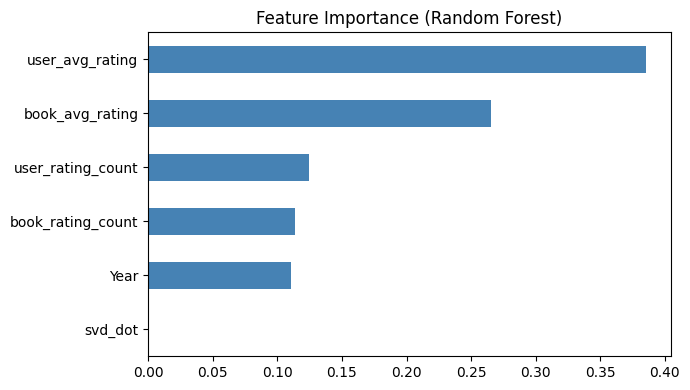


Best Model: Gradient Boosting  (RMSE = 1.3847)
Predicted rating for User 277203 on 'The Cat in the Hat': 9.30 / 10


np.float64(9.29808633943479)

In [ ]:
TEST_BOOK = "Classical Mythology"

print("\n" + "="*60)
print(f"  Recommendations for: '{TEST_BOOK}'")
print("="*60)

print("\n── Content-Based ──")
cb_recs = content_based_recommend(TEST_BOOK, n=10)
print(cb_recs.to_string(index=False))

print("\n── Collaborative Filtering ──")
cf_recs = collab_recommend(TEST_BOOK, n=10)
print(cf_recs.to_string(index=False))

print("\n── Hybrid (50/50) ──")
hybrid_recs = hybrid_recommend(TEST_BOOK, n=10)
print(hybrid_recs.to_string(index=False))

if not hybrid_recs.empty:
    div = intra_list_diversity(hybrid_recs["Title"].tolist())
    print(f"\nDiversity Score: {div}  (0 = all same, 1 = fully diverse)")

print("\n── Catalog Coverage ──")
sample_titles = [TEST_BOOK, "Clara Callan", "Decision in Normandy"]
catalog_coverage(hybrid_recommend, sample_titles, n=10)

print("\n" + "="*60)
print("  RATING PREDICTION (Regression)")
print("="*60)

trained_models, reg_scaler, feat_cols, reg_results = train_regression_models(
    ratings, books, svd, pivot
)

SAMPLE_USER = ratings["User-ID"].iloc[0]
SAMPLE_ISBN = ratings["ISBN"].iloc[0]

predict_rating(SAMPLE_USER, SAMPLE_ISBN, trained_models, ratings, books, svd, pivot,
               model_name="Gradient Boosting")

In [ ]:
import joblib

print("Saving models to disk...")

books.to_pickle("cleaned_books.pkl")
ratings.to_pickle("cleaned_ratings.pkl")

joblib.dump(tfidf_matrix, "tfidf_matrix.pkl")
joblib.dump(title_to_idx, "title_to_idx.pkl")

joblib.dump(collab_sim, "collab_sim.pkl")
joblib.dump(collab_title_to_idx, "collab_title_to_idx.pkl")
joblib.dump(book_titles_list, "book_titles_list.pkl")

joblib.dump(trained_models, "trained_models.pkl")
joblib.dump(svd, "svd_model.pkl")
joblib.dump(pivot, "pivot_table.pkl")

print("Done! All models saved as .pkl files.")

Saving models to disk...
Done! All models saved as .pkl files.
